# Run RIBOMap transfer

This notebook starts from real H5AD inputs and writes a fresh ranking, panel, evaluation and run manifest. [Open the editable source notebook on GitHub](https://github.com/fym0503/SMITH/blob/main/docs/source/tutorials/notebooks/ribomap_section/03_SMITH_RIBOMap_Transfer_source.ipynb).

## Set data and output locations

In [1]:
from pathlib import Path
import hashlib
import json
import os
import subprocess
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def find_repository(start):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "reproducibility").exists():
            return candidate
    raise RuntimeError("Run this notebook inside a SMITH repository checkout.")

ROOT = find_repository(Path.cwd().resolve())
DATA_ROOT = Path(os.environ.get("SMITH_TUTORIAL_DATA", "data/tutorials")).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get("SMITH_TUTORIAL_OUTPUT", "outputs/tutorials")).expanduser().resolve()
CASE_OUTPUT = OUTPUT_ROOT / 'ribomap'
EPOCHS = int(os.environ.get("SMITH_TUTORIAL_EPOCHS", '1'))
DEVICE = os.environ.get("SMITH_TUTORIAL_DEVICE", 'cpu')
print("Input and output roots are configured. Set SMITH_TUTORIAL_DATA/OUTPUT to override them.")

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


Input and output roots are configured. Set SMITH_TUTORIAL_DATA/OUTPUT to override them.


## Check real input files

In [2]:
inputs = ['ribomap_transfer/ribomap/deep_brain_ribomap.h5ad', 'ribomap_transfer/ribomap/mouse_brain_ribomap_rep1.h5ad', 'ribomap_transfer/ribomap/mouse_brain_ribomap_rep2.h5ad']
input_rows = []
for relative in inputs:
    path = DATA_ROOT / relative
    if not path.is_file():
        raise FileNotFoundError(f"Missing {path}. Run scripts/download_tutorial_data.py first.")
    digest = sha256_file(path)
    input_rows.append({"file": relative, "bytes": path.stat().st_size, "sha256": digest})
display(pd.DataFrame(input_rows))


,file,bytes,sha256
0,ribomap_transfer/ribomap/deep_brain_ribomap.h5ad,142886875,c27939e85d6a0e958e09b07807c7d721f8b993b392a444...
1,ribomap_transfer/ribomap/mouse_brain_ribomap_r...,90291819,4551431e38ff5dac9746f4e1495997dc9c4a88c5715b87...
2,ribomap_transfer/ribomap/mouse_brain_ribomap_r...,72496557,601b83c65a392865d8a82f9d4fbed00f7bdbf7ccb52426...


## Run the workflow

In [3]:
command = [
    sys.executable, str(ROOT / 'reproducibility/workflows/ribomap_transfer/run_tutorial.py'),
    "--data-root", str(DATA_ROOT),
    "--output-dir", str(CASE_OUTPUT),
    "--device", DEVICE,
    "--epochs", str(EPOCHS),
    "--seed", "42",
] + ['--panel-size', '64', '--max-cells', '3000']
display_command = [
    "python", 'reproducibility/workflows/ribomap_transfer/run_tutorial.py', "--data-root", "data/tutorials",
    "--output-dir", "outputs/tutorials/ribomap", "--device", DEVICE,
    "--epochs", str(EPOCHS), "--seed", "42",
] + ['--panel-size', '64', '--max-cells', '3000']
print(" ".join(display_command))
completed = subprocess.run(command, cwd=ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
if completed.returncode:
    print(completed.stdout)
    raise subprocess.CalledProcessError(completed.returncode, command)
manifest = json.loads((CASE_OUTPUT / "run_manifest.json").read_text())
print("Completed:", manifest["workflow"], "->", "outputs/tutorials/ribomap/run_manifest.json")


python reproducibility/workflows/ribomap_transfer/run_tutorial.py --data-root data/tutorials --output-dir outputs/tutorials/ribomap --device cpu --epochs 1 --seed 42 --panel-size 64 --max-cells 3000


Completed: 03_ribomap_transfer -> outputs/tutorials/ribomap/run_manifest.json


## Inspect newly generated outputs

In [4]:
panel_path = CASE_OUTPUT / 'smith/panel_top64.csv'
ranking_path = sorted(CASE_OUTPUT.glob('smith/ranking/epoch_*.csv'))[-1]
metrics_path = CASE_OUTPUT / 'evaluation/metrics.tsv'
panel = pd.read_csv(panel_path, sep="\t" if panel_path.suffix == ".tsv" else ",")
ranking = pd.read_csv(ranking_path, sep="\t" if ranking_path.suffix == ".tsv" else ",")
metrics = pd.read_csv(metrics_path, sep="\t")
print("Generated panel:", panel_path.relative_to(CASE_OUTPUT))
display(panel.head(15))
print("Generated ranking:", ranking_path.relative_to(CASE_OUTPUT))
display(ranking.head(10))
display(metrics)


Generated panel: smith/panel_top64.csv


,marker
0,GAD1
1,VIP
2,SST
3,NPY
4,PPP1R1B
5,PVALB
6,SYT2
7,SLC32A1
8,BCL11B
9,TBR1


Generated ranking: smith/ranking/epoch_0.csv


,marker
0,GAD1
1,VIP
2,SST
3,NPY
4,PPP1R1B
5,PVALB
6,SYT2
7,SLC32A1
8,BCL11B
9,TBR1


,dataset,method,metric,value
0,target_1_mouse_brain_ribomap_rep1,SMITH,accuracy,0.290733
1,target_1_mouse_brain_ribomap_rep1,SMITH,balanced_accuracy,0.241936
2,target_1_mouse_brain_ribomap_rep1,SMITH,macro_f1,0.245630
3,target_1_mouse_brain_ribomap_rep1,variance,accuracy,0.347772
4,target_1_mouse_brain_ribomap_rep1,variance,balanced_accuracy,0.273425
5,target_1_mouse_brain_ribomap_rep1,variance,macro_f1,0.270671
6,target_2_mouse_brain_ribomap_rep2,SMITH,accuracy,0.185791
7,target_2_mouse_brain_ribomap_rep2,SMITH,balanced_accuracy,0.142950
8,target_2_mouse_brain_ribomap_rep2,SMITH,macro_f1,0.146393
9,target_2_mouse_brain_ribomap_rep2,variance,accuracy,0.264162


## Analyze this run

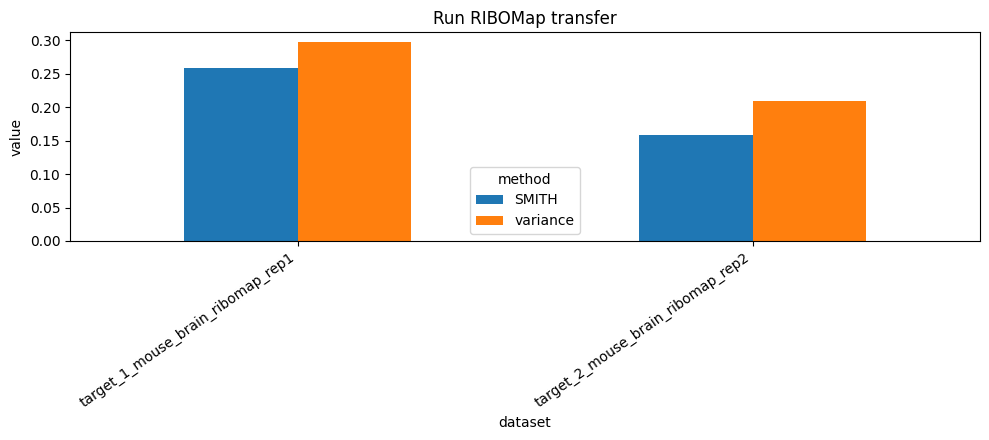

In [5]:
plot_data = metrics.pivot_table(index='dataset', columns='method', values="value", aggfunc="mean")
ax = plot_data.plot(kind="bar", figsize=(10, 4.5))
ax.set_ylabel("value")
ax.set_title('Run RIBOMap transfer')
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## Tutorial run versus manuscript run

This tutorial recomputes shared genes, SMITH and a variance baseline for deep-brain to mouse-brain transfer. The manuscript adds STARmap directions, more baselines and five seeds.